# vLLM Performance Analysis

This notebook covers:
1. Understanding vLLM performance metrics (TTFT, TPOT, E2E)
2. Collecting metrics from the `/metrics` endpoint
3. Running benchmarks at different concurrency levels
4. Interpreting results for mentor presentation

## Key Concepts

### LLM Inference Stages

```
Request arrives
     │
     ▼
┌─────────────┐
│   PREFILL   │  ← Process prompt tokens, populate KV cache
│  (parallel) │    Dominates TTFT (Time To First Token)
└─────────────┘
     │
     ▼
┌─────────────┐
│   DECODE    │  ← Generate output tokens one-by-one
│ (sequential)│    Dominates TPOT (Time Per Output Token)
└─────────────┘
     │
     ▼
Response complete
```

### Metrics Definitions

| Metric | Full Name | What It Measures |
|--------|-----------|------------------|
| **TTFT** | Time To First Token | Latency until first output token (prefill time) |
| **TPOT** | Time Per Output Token | Average time per generated token (decode speed) |
| **E2E** | End-to-End Latency | Total request time (TTFT + decode time) |

### Concurrency vs Num-Requests

| Parameter | Meaning |
|-----------|---------|
| `num-requests` | Total requests to send |
| `concurrency` | How many run simultaneously |

Example: `num-requests=20, concurrency=4` → 20 requests sent 4 at a time (5 batches)

## 1. Setup and Configuration

In [1]:
import subprocess
import requests
import json
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

# Configuration
VLLM_HOST = "localhost"
VLLM_PORT = 8000
BENCHMARK_VARY_IMAGES = False  # False = same image (prefix-cache-friendly), True = different images (production-like)
SCENARIO_LABEL = "Different images (production-like)" if BENCHMARK_VARY_IMAGES else "Same image (prefix-cache-friendly)"

print(f"vLLM server: http://{VLLM_HOST}:{VLLM_PORT}")
print(f"Benchmark scenario: {SCENARIO_LABEL}")
if not BENCHMARK_VARY_IMAGES:
    print("⚠️ Note: same-image mode may overstate production throughput due to prefix caching.")

vLLM server: http://localhost:8000
Benchmark scenario: Same image (prefix-cache-friendly)
⚠️ Note: same-image mode may overstate production throughput due to prefix caching.


## 2. Check Server Health

In [2]:
# Health check
try:
    response = requests.get(f"http://{VLLM_HOST}:{VLLM_PORT}/health", timeout=5)
    print(f"Server status: {'Healthy ✓' if response.status_code == 200 else 'Unhealthy ✗'}")
except Exception as e:
    print(f"Server not reachable: {e}")

Server status: Healthy ✓


In [3]:
# List available models
try:
    response = requests.get(f"http://{VLLM_HOST}:{VLLM_PORT}/v1/models", timeout=5)
    models = response.json()
    print("Available models:")
    for model in models.get("data", []):
        print(f"  - {model['id']}")
except Exception as e:
    print(f"Could not list models: {e}")

Available models:
  - qwen2vl-nutrition


## 3. Understanding the /metrics Endpoint

vLLM exposes Prometheus-style metrics at `/metrics`. Let's fetch and parse them.

In [4]:
# Fetch raw metrics (this is what `curl http://localhost:8000/metrics | grep vllm` does)
def fetch_raw_metrics():
    """Fetch raw metrics from vLLM server."""
    response = requests.get(f"http://{VLLM_HOST}:{VLLM_PORT}/metrics")
    return response.text

# Show a sample of the metrics
raw_metrics = fetch_raw_metrics()
vllm_lines = [line for line in raw_metrics.split('\n') if line.startswith('vllm:')]
print(f"Total vLLM metrics: {len(vllm_lines)}")
print("\nFirst 20 metrics:")
for line in vllm_lines[:20]:
    print(line)

Total vLLM metrics: 331

First 20 metrics:
vllm:num_requests_running{engine="0",model_name="qwen2vl-nutrition"} 0.0
vllm:num_requests_waiting{engine="0",model_name="qwen2vl-nutrition"} 0.0
vllm:engine_sleep_state{engine="0",model_name="qwen2vl-nutrition",sleep_state="awake"} 1.0
vllm:engine_sleep_state{engine="0",model_name="qwen2vl-nutrition",sleep_state="weights_offloaded"} 0.0
vllm:engine_sleep_state{engine="0",model_name="qwen2vl-nutrition",sleep_state="discard_all"} 0.0
vllm:kv_cache_usage_perc{engine="0",model_name="qwen2vl-nutrition"} 0.0
vllm:prefix_cache_queries_total{engine="0",model_name="qwen2vl-nutrition"} 91560.0
vllm:prefix_cache_queries_created{engine="0",model_name="qwen2vl-nutrition"} 1.7705001906702166e+09
vllm:prefix_cache_hits_total{engine="0",model_name="qwen2vl-nutrition"} 89424.0
vllm:prefix_cache_hits_created{engine="0",model_name="qwen2vl-nutrition"} 1.7705001906702507e+09
vllm:external_prefix_cache_queries_total{engine="0",model_name="qwen2vl-nutrition"} 0.0


### Key Metrics to Focus On

From the raw output above, here are the metrics your mentor cares about:

| Metric Name | What It Measures |
|-------------|------------------|
| `vllm:time_to_first_token_seconds` | TTFT - dominated by prefill |
| `vllm:request_time_per_output_token_seconds` | TPOT - decode speed |
| `vllm:e2e_request_latency_seconds` | E2E - total request time |
| `vllm:request_prefill_time_seconds` | Time in prefill phase |
| `vllm:request_decode_time_seconds` | Time in decode phase |
| `vllm:num_requests_running` | Current concurrent requests |
| `vllm:num_requests_waiting` | Queued requests |
| `vllm:kv_cache_usage_perc` | KV cache utilization |

In [5]:
def parse_prometheus_metric(lines: list, metric_name: str) -> float:
    """Parse a specific metric value from Prometheus format."""
    for line in lines:
        if line.startswith(metric_name) and not line.startswith("#"):
            # Handle metrics with labels like vllm:metric{engine="0",...} value
            if "{" in line:
                parts = line.split("} ")
                if len(parts) == 2:
                    try:
                        return float(parts[1])
                    except ValueError:
                        pass
            else:
                parts = line.split()
                if len(parts) >= 2:
                    try:
                        return float(parts[1])
                    except ValueError:
                        pass
    return 0.0


def get_current_metrics() -> dict:
    """Get current metrics in a readable format."""
    response = requests.get(f"http://{VLLM_HOST}:{VLLM_PORT}/metrics")
    lines = response.text.split("\n")

    # Extract key metrics
    ttft_sum = parse_prometheus_metric(lines, "vllm:time_to_first_token_seconds_sum")
    ttft_count = parse_prometheus_metric(lines, "vllm:time_to_first_token_seconds_count")

    tpot_sum = parse_prometheus_metric(lines, "vllm:request_time_per_output_token_seconds_sum")
    tpot_count = parse_prometheus_metric(lines, "vllm:request_time_per_output_token_seconds_count")

    e2e_sum = parse_prometheus_metric(lines, "vllm:e2e_request_latency_seconds_sum")
    e2e_count = parse_prometheus_metric(lines, "vllm:e2e_request_latency_seconds_count")

    prefill_sum = parse_prometheus_metric(lines, "vllm:request_prefill_time_seconds_sum")
    decode_sum = parse_prometheus_metric(lines, "vllm:request_decode_time_seconds_sum")

    return {
        "total_requests": int(ttft_count),
        "avg_ttft_ms": (ttft_sum / ttft_count * 1000) if ttft_count > 0 else 0,
        "avg_tpot_ms": (tpot_sum / tpot_count * 1000) if tpot_count > 0 else 0,
        "avg_e2e_ms": (e2e_sum / e2e_count * 1000) if e2e_count > 0 else 0,
        "avg_prefill_ms": (prefill_sum / ttft_count * 1000) if ttft_count > 0 else 0,
        "avg_decode_ms": (decode_sum / ttft_count * 1000) if ttft_count > 0 else 0,
        "requests_running": int(parse_prometheus_metric(lines, "vllm:num_requests_running")),
        "requests_waiting": int(parse_prometheus_metric(lines, "vllm:num_requests_waiting")),
        "kv_cache_usage": parse_prometheus_metric(lines, "vllm:kv_cache_usage_perc"),
        "prompt_tokens_total": int(parse_prometheus_metric(lines, "vllm:prompt_tokens_total")),
        "generation_tokens_total": int(parse_prometheus_metric(lines, "vllm:generation_tokens_total")),
    }


# Display current metrics
metrics = get_current_metrics()
print("Current vLLM Metrics (cumulative since server start):")
print("=" * 50)
print(f"Total requests processed: {metrics['total_requests']}")
print(f"")
print(f"Average TTFT:    {metrics['avg_ttft_ms']:.1f} ms")
print(f"Average TPOT:    {metrics['avg_tpot_ms']:.1f} ms")
print(f"Average E2E:     {metrics['avg_e2e_ms']:.1f} ms")
print(f"")
print(f"Average Prefill: {metrics['avg_prefill_ms']:.1f} ms")
print(f"Average Decode:  {metrics['avg_decode_ms']:.1f} ms")
print(f"")
print(f"Requests running: {metrics['requests_running']}")
print(f"Requests waiting: {metrics['requests_waiting']}")
print(f"KV cache usage:   {metrics['kv_cache_usage']:.1%}")

Current vLLM Metrics (cumulative since server start):
Total requests processed: 70

Average TTFT:    82.1 ms
Average TPOT:    20.7 ms
Average E2E:     558.3 ms

Average Prefill: 34.4 ms
Average Decode:  476.4 ms

Requests running: 0
Requests waiting: 0
KV cache usage:   0.0%


## 4. Interpreting the Metrics

Let's break down what these numbers mean:

In [6]:
if metrics['total_requests'] == 0:
    display(Markdown("""
### Metrics Interpretation

No requests have been processed yet (server just started). This section shows cumulative
metrics from the `/metrics` endpoint — it will have meaningful data if you re-run after
the benchmarks below, or if the server already has traffic.

**Skip ahead to Section 5 for benchmark results.**
"""))
else:
    tpot_tps = f"~{1000/metrics['avg_tpot_ms']:.0f}" if metrics['avg_tpot_ms'] > 0 else "N/A"

    display(Markdown(f"""
### Metrics Interpretation

Based on **{metrics['total_requests']} requests** processed so far:

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **TTFT** | {metrics['avg_ttft_ms']:.1f} ms | Time until first token. Dominated by **prefill** (processing prompt + populating KV cache) |
| **TPOT** | {metrics['avg_tpot_ms']:.1f} ms | Time per output token. Reflects **decode speed** ({tpot_tps} tokens/sec) |
| **E2E** | {metrics['avg_e2e_ms']:.1f} ms | Total request time. E2E ≈ TTFT + (num_output_tokens × TPOT) |
| **Prefill** | {metrics['avg_prefill_ms']:.1f} ms | Actual prefill computation time |
| **Decode** | {metrics['avg_decode_ms']:.1f} ms | Actual decode computation time |

### Key Insight: Prefill vs Decode

- **Prefill time ({metrics['avg_prefill_ms']:.1f} ms)** is dominated by processing the **image** (VLM-specific)
- **Decode time ({metrics['avg_decode_ms']:.1f} ms)** is for generating ~{metrics['generation_tokens_total'] // max(metrics['total_requests'], 1)} tokens per request
- For our bbox detection task, decode is fast because output is short (~22 tokens)

### Token Statistics

- Total prompt tokens: {metrics['prompt_tokens_total']:,} ({metrics['prompt_tokens_total'] // max(metrics['total_requests'], 1):,} per request)
- Total generation tokens: {metrics['generation_tokens_total']:,} ({metrics['generation_tokens_total'] // max(metrics['total_requests'], 1):,} per request)
"""))


### Metrics Interpretation

Based on **70 requests** processed so far:

| Metric | Value | Interpretation |
|--------|-------|----------------|
| **TTFT** | 82.1 ms | Time until first token. Dominated by **prefill** (processing prompt + populating KV cache) |
| **TPOT** | 20.7 ms | Time per output token. Reflects **decode speed** (~48 tokens/sec) |
| **E2E** | 558.3 ms | Total request time. E2E ≈ TTFT + (num_output_tokens × TPOT) |
| **Prefill** | 34.4 ms | Actual prefill computation time |
| **Decode** | 476.4 ms | Actual decode computation time |

### Key Insight: Prefill vs Decode

- **Prefill time (34.4 ms)** is dominated by processing the **image** (VLM-specific)
- **Decode time (476.4 ms)** is for generating ~24 tokens per request
- For our bbox detection task, decode is fast because output is short (~22 tokens)

### Token Statistics

- Total prompt tokens: 91,560 (1,308 per request)
- Total generation tokens: 1,680 (24 per request)


## 5. Running Benchmarks

Now let's run the benchmark script at different concurrency levels.

In [7]:
import sys
sys.path.insert(0, '/home/zhuoyuan/projects/vlm_Qwen2VL_object_detection')

# Import the benchmark function
from scripts.benchmark_vllm import run_benchmark, get_metrics_snapshot

/ssd1/zhuoyuan/envs/qwen2vl_nutrition_vllm_serving/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/ssd1/zhuoyuan/envs/qwen2vl_nutrition_vllm_serving/lib/python3.12/site-packages/torch/cuda/__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


### Experiment 1: Baseline (Single Request)

First, let's establish a baseline with sequential requests (concurrency=1).
This notebook defaults to SAME-IMAGE mode unless `BENCHMARK_VARY_IMAGES=True`.

In [8]:
# Run baseline benchmark
print("Running Experiment 1: Baseline (concurrency=1)")
print("-" * 50)
baseline_results = run_benchmark(
    num_requests=10,
    concurrency=1,
    vary_images=BENCHMARK_VARY_IMAGES,
    verbose=True,
)

Running Experiment 1: Baseline (concurrency=1)
--------------------------------------------------
vLLM Benchmark: 10 requests @ concurrency=1
  Image mode: SAME image (best-case caching)

1. Loading test images from HuggingFace dataset...


   Using same image for all requests (size: (3120, 4208))

2. Capturing initial VRAM and metrics...
   Initial VRAM usage: 23211 MB (22.67 GB)

3. Running 10 requests with concurrency=1...



4. Capturing final metrics and VRAM...
   Final VRAM usage: 23211 MB (22.67 GB)
   Peak VRAM usage: 23211 MB (22.67 GB)
   KV Cache usage: 0.0%

BENCHMARK RESULTS

[Configuration]
  Requests: 10
  Concurrency: 1

[Summary]
  Successful: 10/10
  Total time: 5.09s
  Throughput: 1.96 req/s

[Client-Side Latency]
  Avg: 508.7 ms
  Min: 499.4 ms
  Max: 541.5 ms

[Server-Side Metrics (from /metrics)]
  Avg TTFT: 28.6 ms
  Avg TPOT: 20.2 ms
  Avg ITL:  20.2 ms (inter-token latency)
  Avg E2E:  492.4 ms
  Avg Prefill: 24.9 ms
  Avg Decode:  463.7 ms
  Tokens (prompt/gen): 13080/240

[VRAM Usage]
  Initial: 22.67 GB
  Peak:    22.67 GB
  Final:   22.67 GB
  KV Cache: 0.0%



In [9]:
# Store results for comparison
all_results = []
all_results.append({
    "scenario": SCENARIO_LABEL,
    "vary_images": BENCHMARK_VARY_IMAGES,
    "concurrency": 1,
    "num_requests": 10,
    **baseline_results["summary"],
    **baseline_results["client_metrics"],
    **baseline_results["server_metrics"]
})

### Experiment 2: Concurrency Scaling

Now let's test with increasing concurrency to see how latency changes under load.
We'll test concurrency levels: 1, 2, 4, 8

In [10]:
# Test different concurrency levels
concurrency_levels = [1, 2, 4, 8]

for conc in concurrency_levels[1:]:  # Skip 1, we already did it
    print(f"\n{'='*60}")
    print(f"Running benchmark with concurrency={conc}")
    print("=" * 60)

    results = run_benchmark(
        num_requests=20,
        concurrency=conc,
        vary_images=BENCHMARK_VARY_IMAGES,
        verbose=True,
    )

    all_results.append({
        "scenario": SCENARIO_LABEL,
        "vary_images": BENCHMARK_VARY_IMAGES,
        "concurrency": conc,
        "num_requests": 20,
        **results["summary"],
        **results["client_metrics"],
        **results["server_metrics"]
    })


Running benchmark with concurrency=2
vLLM Benchmark: 20 requests @ concurrency=2
  Image mode: SAME image (best-case caching)

1. Loading test images from HuggingFace dataset...


   Using same image for all requests (size: (3120, 4208))

2. Capturing initial VRAM and metrics...
   Initial VRAM usage: 23211 MB (22.67 GB)

3. Running 20 requests with concurrency=2...



4. Capturing final metrics and VRAM...
   Final VRAM usage: 23211 MB (22.67 GB)
   Peak VRAM usage: 23211 MB (22.67 GB)
   KV Cache usage: 0.0%

BENCHMARK RESULTS

[Configuration]
  Requests: 20
  Concurrency: 2

[Summary]
  Successful: 20/20
  Total time: 5.17s
  Throughput: 3.87 req/s

[Client-Side Latency]
  Avg: 515.4 ms
  Min: 509.7 ms
  Max: 550.2 ms

[Server-Side Metrics (from /metrics)]
  Avg TTFT: 30.5 ms
  Avg TPOT: 20.3 ms
  Avg ITL:  20.3 ms (inter-token latency)
  Avg E2E:  497.8 ms
  Avg Prefill: 22.5 ms
  Avg Decode:  467.4 ms
  Tokens (prompt/gen): 26160/480

[VRAM Usage]
  Initial: 22.67 GB
  Peak:    22.67 GB
  Final:   22.67 GB
  KV Cache: 0.0%


Running benchmark with concurrency=4
vLLM Benchmark: 20 requests @ concurrency=4
  Image mode: SAME image (best-case caching)

1. Loading test images from HuggingFace dataset...


   Using same image for all requests (size: (3120, 4208))

2. Capturing initial VRAM and metrics...
   Initial VRAM usage: 23211 MB (22.67 GB)

3. Running 20 requests with concurrency=4...



4. Capturing final metrics and VRAM...
   Final VRAM usage: 23211 MB (22.67 GB)
   Peak VRAM usage: 23211 MB (22.67 GB)
   KV Cache usage: 0.0%

BENCHMARK RESULTS

[Configuration]
  Requests: 20
  Concurrency: 4

[Summary]
  Successful: 20/20
  Total time: 2.75s
  Throughput: 7.27 req/s

[Client-Side Latency]
  Avg: 541.3 ms
  Min: 523.3 ms
  Max: 575.7 ms

[Server-Side Metrics (from /metrics)]
  Avg TTFT: 39.4 ms
  Avg TPOT: 20.7 ms
  Avg ITL:  20.7 ms (inter-token latency)
  Avg E2E:  516.4 ms
  Avg Prefill: 24.0 ms
  Avg Decode:  477.2 ms
  Tokens (prompt/gen): 26160/480

[VRAM Usage]
  Initial: 22.67 GB
  Peak:    22.67 GB
  Final:   22.67 GB
  KV Cache: 0.0%


Running benchmark with concurrency=8
vLLM Benchmark: 20 requests @ concurrency=8
  Image mode: SAME image (best-case caching)

1. Loading test images from HuggingFace dataset...


   Using same image for all requests (size: (3120, 4208))

2. Capturing initial VRAM and metrics...
   Initial VRAM usage: 23211 MB (22.67 GB)

3. Running 20 requests with concurrency=8...



4. Capturing final metrics and VRAM...
   Final VRAM usage: 23211 MB (22.67 GB)
   Peak VRAM usage: 23211 MB (22.67 GB)
   KV Cache usage: 0.0%

BENCHMARK RESULTS

[Configuration]
  Requests: 20
  Concurrency: 8

[Summary]
  Successful: 20/20
  Total time: 1.74s
  Throughput: 11.47 req/s

[Client-Side Latency]
  Avg: 583.7 ms
  Min: 523.2 ms
  Max: 642.5 ms

[Server-Side Metrics (from /metrics)]
  Avg TTFT: 45.2 ms
  Avg TPOT: 21.3 ms
  Avg ITL:  21.3 ms (inter-token latency)
  Avg E2E:  534.3 ms
  Avg Prefill: 28.0 ms
  Avg Decode:  489.1 ms
  Tokens (prompt/gen): 26160/480

[VRAM Usage]
  Initial: 22.67 GB
  Peak:    22.67 GB
  Final:   22.67 GB
  KV Cache: 0.0%



## 6. Results Analysis

In [11]:
# Create results DataFrame
df = pd.DataFrame(all_results)

# Display results table
print("\nBenchmark Results Summary")
print("=" * 80)
print(f"Scenario: {SCENARIO_LABEL}")

# Check if avg_itl_ms exists (may not in older runs)
cols_to_show = ["scenario", "concurrency", "num_requests", "successful_requests", "throughput_rps",
                "avg_ttft_ms", "avg_tpot_ms", "avg_e2e_ms", "avg_latency_ms"]
if "avg_itl_ms" in df.columns:
    cols_to_show.insert(7, "avg_itl_ms")  # Add ITL after TPOT

display(df[cols_to_show].round(2))


Benchmark Results Summary
Scenario: Same image (prefix-cache-friendly)


,scenario,concurrency,num_requests,successful_requests,throughput_rps,avg_ttft_ms,avg_tpot_ms,avg_itl_ms,avg_e2e_ms,avg_latency_ms
0,Same image (prefix-cache-friendly),1,10,10,1.96,28.62,20.16,20.16,492.38,508.74
1,Same image (prefix-cache-friendly),2,20,20,3.87,30.51,20.32,20.32,497.83,515.37
2,Same image (prefix-cache-friendly),4,20,20,7.27,39.38,20.75,20.75,516.37,541.34
3,Same image (prefix-cache-friendly),8,20,20,11.47,45.17,21.26,21.26,534.31,583.67


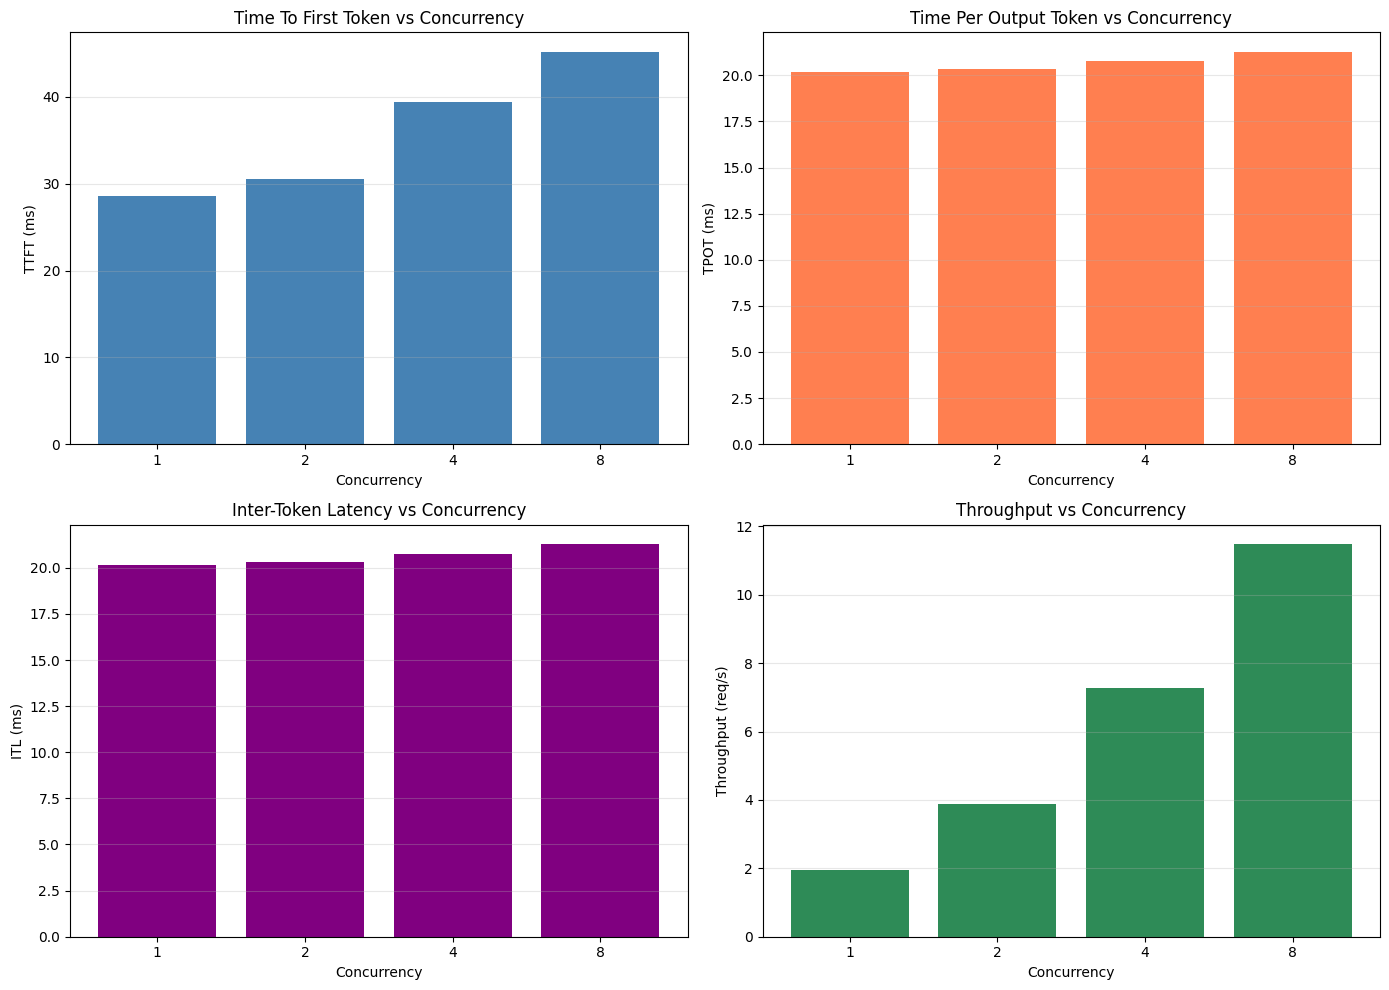


Plot saved to: /tmp/vllm_benchmark_results.png


In [12]:
# Visualization: Latency vs Concurrency
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: TTFT vs Concurrency
axes[0, 0].bar(df["concurrency"].astype(str), df["avg_ttft_ms"], color='steelblue')
axes[0, 0].set_xlabel("Concurrency")
axes[0, 0].set_ylabel("TTFT (ms)")
axes[0, 0].set_title("Time To First Token vs Concurrency")
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: TPOT vs Concurrency
axes[0, 1].bar(df["concurrency"].astype(str), df["avg_tpot_ms"], color='coral')
axes[0, 1].set_xlabel("Concurrency")
axes[0, 1].set_ylabel("TPOT (ms)")
axes[0, 1].set_title("Time Per Output Token vs Concurrency")
axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Inter-Token Latency vs Concurrency
if "avg_itl_ms" in df.columns:
    axes[1, 0].bar(df["concurrency"].astype(str), df["avg_itl_ms"], color='purple')
    axes[1, 0].set_xlabel("Concurrency")
    axes[1, 0].set_ylabel("ITL (ms)")
    axes[1, 0].set_title("Inter-Token Latency vs Concurrency")
    axes[1, 0].grid(axis='y', alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'ITL data not available', ha='center', va='center')
    axes[1, 0].set_title("Inter-Token Latency vs Concurrency")

# Plot 4: Throughput vs Concurrency
axes[1, 1].bar(df["concurrency"].astype(str), df["throughput_rps"], color='seagreen')
axes[1, 1].set_xlabel("Concurrency")
axes[1, 1].set_ylabel("Throughput (req/s)")
axes[1, 1].set_title("Throughput vs Concurrency")
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("/tmp/vllm_benchmark_results.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: /tmp/vllm_benchmark_results.png")

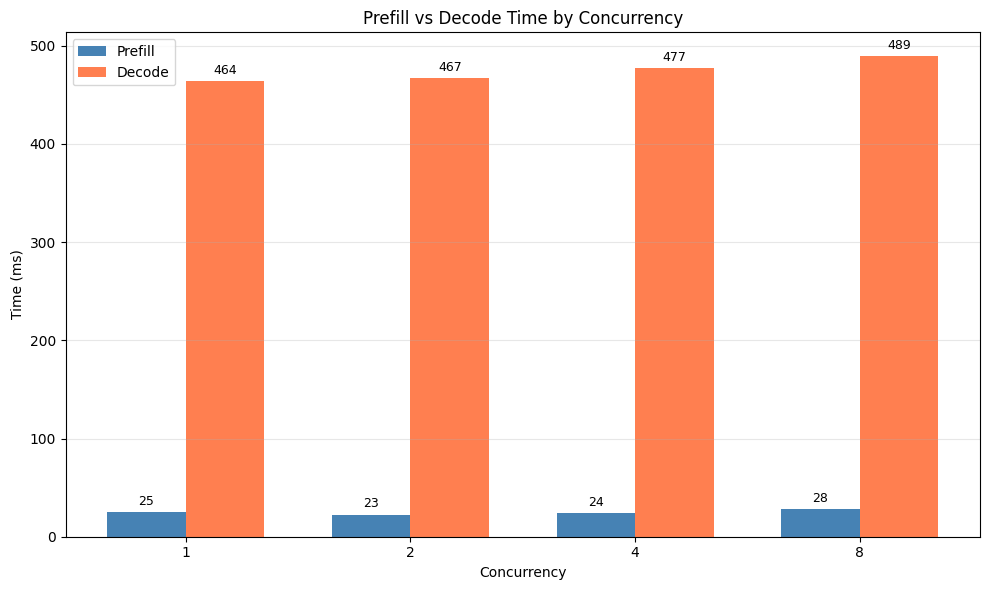


Plot saved to: /tmp/vllm_prefill_decode_breakdown.png


In [13]:
# Visualization: Prefill vs Decode time breakdown
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], df["avg_prefill_ms"], width, label='Prefill', color='steelblue')
bars2 = ax.bar([i + width/2 for i in x], df["avg_decode_ms"], width, label='Decode', color='coral')

ax.set_xlabel("Concurrency")
ax.set_ylabel("Time (ms)")
ax.set_title("Prefill vs Decode Time by Concurrency")
ax.set_xticks(x)
ax.set_xticklabels(df["concurrency"].astype(str))
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.annotate(f'{height:.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.0f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("/tmp/vllm_prefill_decode_breakdown.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nPlot saved to: /tmp/vllm_prefill_decode_breakdown.png")

## 7. Key Findings Summary

In [14]:
# Generate summary for mentor
baseline = df[df["concurrency"] == 1].iloc[0] if len(df[df["concurrency"] == 1]) > 0 else df.iloc[0]
max_conc = df[df["concurrency"] == df["concurrency"].max()].iloc[0]

baseline_tps = f"~{1000/baseline['avg_tpot_ms']:.0f}" if baseline['avg_tpot_ms'] > 0 else "N/A"

display(Markdown(f"""
## Summary

**Scenario measured:** {SCENARIO_LABEL}

### Baseline Performance (concurrency=1)
- **TTFT**: {baseline['avg_ttft_ms']:.1f} ms (time to first token)
- **TPOT**: {baseline['avg_tpot_ms']:.1f} ms (time per output token)
- **E2E**: {baseline['avg_e2e_ms']:.1f} ms (end-to-end latency)
- **Throughput**: {baseline['throughput_rps']:.2f} req/s

### At Higher Concurrency (concurrency={int(max_conc['concurrency'])})
- **TTFT**: {max_conc['avg_ttft_ms']:.1f} ms ({(max_conc['avg_ttft_ms']/baseline['avg_ttft_ms']-1)*100:+.1f}% vs baseline)
- **TPOT**: {max_conc['avg_tpot_ms']:.1f} ms ({(max_conc['avg_tpot_ms']/baseline['avg_tpot_ms']-1)*100:+.1f}% vs baseline)
- **Throughput**: {max_conc['throughput_rps']:.2f} req/s ({(max_conc['throughput_rps']/baseline['throughput_rps']-1)*100:+.1f}% vs baseline)

### Key Observations

1. **Prefill dominates TTFT**: For VLMs with image input, prefill time is significant due to image processing

2. **Decode is fast**: Output tokens are generated quickly ({baseline_tps} tokens/sec) because:
   - Our bbox output is short (~22 tokens)
   - KV cache reuse makes decode efficient

3. **Concurrency tradeoff**:
   - Higher concurrency → Higher throughput
   - But also → Higher per-request latency
   - vLLM batches tokens across concurrent requests

4. **Interpretation warning**:
   - If scenario is **Same image (prefix-cache-friendly)**, throughput/latency can look better than production.
   - For production-like numbers, rerun with `BENCHMARK_VARY_IMAGES=True`.

### How to Report

> "In the **{SCENARIO_LABEL}** scenario, at concurrency={int(baseline['concurrency'])}, our model achieves {baseline['avg_ttft_ms']:.0f}ms TTFT and {baseline['avg_e2e_ms']:.0f}ms E2E latency.
> At concurrency={int(max_conc['concurrency'])}, throughput increases to {max_conc['throughput_rps']:.2f} req/s
> ({max_conc['throughput_rps']/baseline['throughput_rps']:.1f}x baseline)."
"""))


## Summary

**Scenario measured:** Same image (prefix-cache-friendly)

### Baseline Performance (concurrency=1)
- **TTFT**: 28.6 ms (time to first token)
- **TPOT**: 20.2 ms (time per output token)
- **E2E**: 492.4 ms (end-to-end latency)
- **Throughput**: 1.96 req/s

### At Higher Concurrency (concurrency=8)
- **TTFT**: 45.2 ms (+57.9% vs baseline)
- **TPOT**: 21.3 ms (+5.5% vs baseline)
- **Throughput**: 11.47 req/s (+483.8% vs baseline)

### Key Observations

1. **Prefill dominates TTFT**: For VLMs with image input, prefill time is significant due to image processing

2. **Decode is fast**: Output tokens are generated quickly (~50 tokens/sec) because:
   - Our bbox output is short (~22 tokens)
   - KV cache reuse makes decode efficient

3. **Concurrency tradeoff**:
   - Higher concurrency → Higher throughput
   - But also → Higher per-request latency
   - vLLM batches tokens across concurrent requests

4. **Interpretation warning**:
   - If scenario is **Same image (prefix-cache-friendly)**, throughput/latency can look better than production.
   - For production-like numbers, rerun with `BENCHMARK_VARY_IMAGES=True`.

### How to Report

> "In the **Same image (prefix-cache-friendly)** scenario, at concurrency=1, our model achieves 29ms TTFT and 492ms E2E latency.
> At concurrency=8, throughput increases to 11.47 req/s
> (5.8x baseline)."


## 8. Save Results

In [15]:
# Save results to CSV
results_file = "/home/zhuoyuan/projects/vlm_Qwen2VL_object_detection/refactor_documentation/vllm_benchmark_results.csv"
df.to_csv(results_file, index=False)
print(f"Results saved to: {results_file}")
print(f"Scenario saved: {SCENARIO_LABEL}")

# Save as JSON too
json_file = "/home/zhuoyuan/projects/vlm_Qwen2VL_object_detection/refactor_documentation/vllm_benchmark_results.json"
df.to_json(json_file, orient="records", indent=2)
print(f"Results saved to: {json_file}")

Results saved to: /home/zhuoyuan/projects/vlm_Qwen2VL_object_detection/refactor_documentation/vllm_benchmark_results.csv
Scenario saved: Same image (prefix-cache-friendly)
Results saved to: /home/zhuoyuan/projects/vlm_Qwen2VL_object_detection/refactor_documentation/vllm_benchmark_results.json


## Appendix: Raw Metrics Command

To manually check metrics from terminal:
```bash
curl http://localhost:8000/metrics | grep vllm
```

Key metrics to look for:
- `vllm:time_to_first_token_seconds_sum/count` → TTFT
- `vllm:request_time_per_output_token_seconds_sum/count` → TPOT
- `vllm:e2e_request_latency_seconds_sum/count` → E2E
- `vllm:request_prefill_time_seconds_sum` → Prefill time
- `vllm:request_decode_time_seconds_sum` → Decode time